
 Project Title

**Global Superstore Sales Performance Analysis**




## Business Context


The Global Superstore operates across multiple countries, markets, customer segments, and product categories. With over 51,000 transactions,
the company generates substantial revenue but requires deeper analytical insights to understand profitability, customer behavior, product performance,
and operational efficiency.


Although sales continue to grow, management lacks visibility into the factors driving profitability and the areas where strategic improvements
can increase long-term business performance.


This project aims to transform raw transactional data into actionable business insights through exploratory data analysis, statistical investigation,
and data visualization.



# Business Objectives


The analysis seeks to answer several key business questions:


### Revenue Performance


- Which markets generate the highest sales?
- Which categories contribute most to revenue?
- Which countries are driving company growth?


### Profitability


- Which products generate the highest profits?
- Which categories are losing money?
- Does higher revenue always lead to higher profit?


### Customer Behavior


- Which customer segments spend the most?
- Are high-value customers concentrated in specific regions?
- Which customers should receive retention efforts?


### Operational Performance


- Which shipping methods are most efficient?
- Does shipping cost significantly impact profitability?
- Are discounts harming overall margins?


### Strategic Decision Making


The final goal is to provide management with actionable recommendations that improve:


- Revenue Growth
- Profitability
- Customer Retention
- Inventory Planning
- Pricing Strategy
- Logistics Optimization
 


In [247]:
# ==========================================================
# CHAPTER 1 : DATA UNDERSTANDING & DATA QUALITY ASSESSMENT
# ==========================================================
#
# This chapter focuses on understanding the dataset structure,
# evaluating data quality, and identifying potential issues
# before performing any business analysis.
#
# A proper data understanding phase ensures that all subsequent
# insights are based on reliable and consistent information.
# ==========================================================


# Import data manipulation libraries
import pandas as pd
import numpy as np

# Configure pandas display options
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
plt.style.use('ggplot')
sns.set(font_scale=1)

In [248]:
# ==========================================================
# LOAD DATASET
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# The Superstore dataset contains historical sales transactions
# across multiple countries, product categories, customer segments,
# and shipping methods.
#
# It will be used to identify sales patterns, profitability drivers,
# customer behavior, and operational improvement opportunities.
# ==========================================================

df = pd.read_csv("superstore.csv")

df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.00,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.33,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.00,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.29,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.84,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.26,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.00,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.11,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


Business Interpretation

The first five records confirm that each row represents an individual sales transaction.

The dataset captures important business dimensions including:

Customer information
Product details
Sales amount
Profit
Discount
Shipping information
Geographic location
Order dates

This rich transactional structure makes the dataset suitable for sales, profitability, customer, product, and logistics analyses.

In [249]:
# ==========================================================
# DISPLAY LAST OBSERVATIONS
# ==========================================================
#
# Reviewing the last records helps verify that the dataset
# has been imported correctly and that no truncation occurred
# during the loading process.
# ==========================================================

df.tail()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.20,US,1,2014-12-03 00:00:00.000,CA-2014-109701,High,OFF-BI-10000632,Satellite Sectional Post Binders,22.57,2,West,33646,69,Corporate,2014-12-04 00:00:00.000,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.20,US,1,2014-12-03 00:00:00.000,CA-2014-109701,High,OFF-BI-10004187,Staples,3.16,6,West,33645,9,Corporate,2014-12-04 00:00:00.000,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.20,US,1,2014-12-18 00:00:00.000,CA-2014-106964,Medium,OFF-BI-10000320,GBC Plastic Binding Combs,4.28,2,West,32321,12,Home Office,2014-12-21 00:00:00.000,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.20,US,1,2014-12-25 00:00:00.000,CA-2014-145219,Critical,OFF-BI-10001670,Vinyl Sectional Post Binders,33.93,3,West,35917,90,Home Office,2014-12-26 00:00:00.000,First Class,15.95,California,Binders,2014,North America,52
51289,Office Supplies,Los Angeles,United States,FH-143654,Fred Hopkins,0.20,US,1,2014-12-26 00:00:00.000,CA-2014-121398,Medium,OFF-BI-10001718,GBC DocuBind P50 Personal Binding Machine,51.82,3,West,37371,154,Corporate,2014-12-30 00:00:00.000,Standard Class,9.59,California,Binders,2014,North America,52


# Business Interpretation

The dataset appears complete from beginning to end.

No obvious formatting inconsistencies are observed between the first and last records.

This indicates that the import process was successful.

In [250]:
# ==========================================================
# DATASET STRUCTURE
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Understanding the structure of the dataset helps identify:
#
# • Number of observations
# • Number of variables
# • Data types
# • Missing values
#
# This assessment determines the amount of data preparation
# required before conducting business analysis.
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

# Business Insight

The dataset contains 51,290 transactions described by 27 variables, providing a comprehensive view of the company's operations.

The dataset includes a mix of:

Numerical variables (Sales, Profit, Quantity, Discount)
Categorical variables (Category, Segment, Region)
Date variables (Order Date, Ship Date)

No missing values are reported, indicating excellent data completeness.

Overall, the dataset is well-structured and suitable for further analysis with minimal preprocessing.

In [251]:
# ==========================================================
# DESCRIPTIVE STATISTICS
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Summary statistics provide an overview of sales performance,
# pricing, profitability, order size, and shipping costs.
#
# They also help identify unusual values that may require
# further investigation.
# ==========================================================

df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,"51,290.00","51,290.00","51,290.00","51,290.00","51,290.00","51,290.00","51,290.00","51,290.00","51,290.00"
mean,0.14,1.00,28.61,3.48,"25,645.50",246.50,26.38,"2,012.78",31.29
std,0.21,0.00,174.34,2.28,"14,806.29",487.57,57.30,1.10,14.43
min,0.00,1.00,"-6,599.98",1.00,1.00,0.00,0.00,"2,011.00",1.00
25%,0.00,1.00,0.00,2.00,"12,823.25",31.00,2.61,"2,012.00",20.00
50%,0.00,1.00,9.24,3.00,"25,645.50",85.00,7.79,"2,013.00",33.00
75%,0.20,1.00,36.81,5.00,"38,467.75",251.00,24.45,"2,014.00",44.00
max,0.85,1.00,"8,399.98",14.00,"51,290.00","22,638.00",933.57,"2,014.00",53.00


# Business Insight

Several important observations emerge from the summary statistics:

Sales range from 0 Dollar to over 22,000 Dollars, indicating significant variability in order values.
Profit ranges from –$6,599 to 8,400 Dollars, showing that some transactions generate substantial financial losses.
The average discount is 14.3%, suggesting that promotional pricing is a common sales strategy.
Shipping costs vary considerably, reflecting differences in delivery methods or shipment sizes.

These findings indicate that the business manages a diverse portfolio of transactions, from small routine purchases to high-value enterprise orders.

In [252]:
# ==========================================================
# DATASET DIMENSIONS
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Verify the overall size of the dataset to estimate
# analytical complexity and computational requirements.
# ==========================================================

df.shape

(51290, 27)

In [253]:
# ==========================================================
# DATA TYPES
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Correct data types are essential for accurate calculations,
# aggregations, and time-series analysis.
# ==========================================================

df.dtypes

Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
记录数                 int64
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

# Business Insight

Most variables have appropriate data types.

However, the Order Date and Ship Date fields are currently stored as text and will need to be converted into datetime format to enable trend analysis, seasonality studies, and delivery performance evaluation.

In [254]:
# ==========================================================
# MISSING VALUES ASSESSMENT
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Missing values can reduce the accuracy of business analysis,
# introduce bias into KPIs, and affect machine learning models.
#
# This assessment verifies whether critical business fields
# contain incomplete information.
# ==========================================================

df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

## Business Insight

The dataset contains no missing values across all variables.

This indicates excellent data completeness, allowing the analysis to proceed without data imputation or record removal.

Complete datasets improve the reliability of business insights and reduce the risk of biased conclusions.

In [255]:
# ==========================================================
# DUPLICATE RECORD DETECTION
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Duplicate records can artificially inflate sales,
# profit, customer counts, and operational KPIs.
#
# Detecting duplicates ensures that each transaction
# represents a unique business event.
# ==========================================================

df.duplicated().sum()

np.int64(0)

## Business Insight

No duplicate records were identified.

This confirms that every transaction in the dataset is unique, ensuring accurate calculations for revenue, profit, and customer metrics.

In [256]:
# ==========================================================
# UNIQUE VALUES ANALYSIS
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Understanding the cardinality of each variable helps
# distinguish identifiers from analytical dimensions and
# reveals the diversity of products, customers, and markets.
# ==========================================================

df.nunique()

Category              3
City               3636
Country             147
Customer.ID        4873
Customer.Name       795
Discount             27
Market                7
记录数                   1
Order.Date         1430
Order.ID          25035
Order.Priority        4
Product.ID        10292
Product.Name       3788
Profit            24575
Quantity             14
Region               13
Row.ID            51290
Sales              2246
Segment               3
Ship.Date          1464
Ship.Mode             4
Shipping.Cost     16877
State              1094
Sub.Category         17
Year                  4
Market2               6
weeknum              53
dtype: int64

## Business Insight

The business operates across:

• 147 countries
• 3,636 cities
• 10,292 unique products
• 4,873 customer IDs

The high diversity confirms that this is a global retail dataset with a broad customer base and extensive product catalog.

In [257]:
# ==========================================================
# CUSTOMER IDENTIFIER VALIDATION
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Verify whether customer names uniquely identify customers
# or whether Customer_ID should be used as the primary key.
# ==========================================================
print(df['Customer.ID'].nunique())
print(df['Customer.Name'].nunique())

4873
795


## Business Insight

The dataset contains:

• 4,873 unique Customer IDs
• only 795 unique Customer Names

This indicates that customer names are not unique identifiers.

Several different customers share the same name.

Therefore, Customer_ID should always be used for customer-level analysis.

In [183]:
duplicate_name = ( df.groupby('Customer.Name')['Customer.ID'].nunique().sort_values(ascending=False))
duplicate_name[duplicate_name>1]

Customer.Name
Adam Hart               7
Alan Barnes             7
Adrian Barton           7
Alejandro Grove         7
Alejandro Ballentine    7
                       ..
Arthur Gainer           5
Barry Gonzalez          5
Anthony Witt            5
Zuschuss Carroll        5
Adam Shillingsburg      5
Name: Customer.ID, Length: 795, dtype: int64

## Business Insight

Many customer names are associated with multiple Customer IDs.

This confirms that customer names alone cannot uniquely identify individuals.

Using Customer_Name for segmentation or customer lifetime value analysis would lead to inaccurate results.

In [258]:
# ==========================================================
# PRODUCT CATEGORY DISTRIBUTION
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Analyze the distribution of transactions across
# product categories to understand business focus.
# ==========================================================

df["Category"].value_counts()

Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

## Business Insight

Office Supplies accounts for the majority of transactions.

This suggests that the company relies heavily on everyday office products to generate sales volume.

However, transaction volume alone does not necessarily imply higher profitability.

In [260]:
# ==========================================================
# SHIPPING MODE DISTRIBUTION
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Evaluate customers' preferred shipping methods
# and identify operational demand patterns.
# ==========================================================

df["Ship.Mode"].value_counts()

Ship.Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

## Business Insight

Standard Class is by far the most frequently used shipping method.

This suggests that customers generally prioritize lower shipping costs over faster delivery options.

The logistics network should therefore remain optimized for standard shipments.

In [261]:
# ==========================================================
# CUSTOMER SEGMENT DISTRIBUTION
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Identify the company's primary customer segments
# and understand where demand is concentrated.
# ==========================================================

df["Segment"].value_counts()

Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

## Business Insight

Consumer customers represent the largest segment.

This indicates that retail customers contribute the majority of business activity, while Corporate and Home Office customers represent secondary markets.

Marketing campaigns should continue focusing on Consumer customers while exploring growth opportunities in business segments.

In [262]:
# ==========================================================
# REGIONAL DISTRIBUTION
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Examine transaction distribution across regions
# to understand geographic market coverage.
# ==========================================================

df["Region"].value_counts()

Region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

## Business Insight

The Central region records the highest number of transactions.

Regional differences may reflect variations in market size, customer demand, or sales coverage.

Further analysis of Sales and Profit by region will determine whether transaction volume translates into business performance.

In [240]:
# ==========================================================
# DATA CONSISTENCY CHECK
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Verify that Sales, Quantity, and Discount contain
# logically valid business values.
# ==========================================================
(df["Sales"] < 0).sum()

np.int64(0)

In [189]:
(df["Quantity"] < 0).sum()

np.int64(0)

In [190]:
(df["Discount"] < 0).sum()

np.int64(0)

## Business Insight

No negative Sales, Quantity, or Discount values were detected.

This confirms that the dataset is logically consistent and suitable for financial analysis.

The only negative values observed in the dataset relate to Profit, which is expected because some transactions generate financial losses.

In [191]:
# ==========================================================
# REMOVE NON-ANALYTICAL COLUMNS
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Remove variables that provide no analytical value
# or duplicate existing information.
# ==========================================================
df.drop(columns = ['记录数'], inplace = True)

In [192]:
df.drop(columns = ['Row.ID'], inplace = True)

In [193]:
df.drop(columns = ['Market2'], inplace = True)

## Business Insight

The removed variables do not contribute to business decision-making.

Keeping only relevant features improves code readability, simplifies analysis, and reduces memory usage.

In [264]:
# ==========================================================
# STANDARDIZE COLUMN NAMES
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Standardized column names improve code readability
# and facilitate analysis by avoiding spaces and special characters.
# ==========================================================
df.columns = df.columns.str.strip()

In [265]:
df.columns = df.columns.str.strip().str.replace('.','_')

## Business Insight

The dataset now follows a consistent naming convention.

This improves code maintainability and reduces the likelihood of programming errors during analysis.

In [267]:
# ==========================================================
# CONVERT DATE VARIABLES
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Date conversion enables time-series analysis,
# seasonality detection, customer purchasing trends,
# and delivery performance evaluation.
# ==========================================================
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])


## Business Insight

Order_Date and Ship_Date are now stored in datetime format.

This transformation enables advanced analyses such as monthly sales trends, delivery lead times, yearly growth, and seasonal demand patterns.

============================================================

## SUMMARY

============================================================

The data quality assessment confirms that the dataset is highly reliable for business analysis.

Key findings include:

• No missing values.
• No duplicate transactions.
• Consistent numerical values.
• Proper feature standardization.
• Date variables successfully converted to datetime format.
• Customer_ID identified as the correct customer identifier.

Overall, the dataset requires minimal preprocessing, allowing the analysis to focus on generating business insights rather than correcting data quality issues.

In [241]:
# ==========================================================
# SALES OUTLIER DETECTION
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Detect unusually large or small sales transactions.
#
# Outliers may represent:
#
# • Enterprise purchases
# • Pricing anomalies
# • Fraudulent activity
# • Data entry errors
#
# In retail datasets, large transactions often represent
# valuable business opportunities rather than incorrect data.
# ==========================================================

# Calculate the first quartile (25th percentile) of Sales data
Q1 = df["Sales"].quantile(0.25)
# Calculate the third quartile (75th percentile) of Sales data
Q3 = df["Sales"].quantile(0.75)

# Calculate the Interquartile Range (IQR) - the difference between Q3 and Q1
IQR = Q3 - Q1

# Define the lower boundary for outliers using the IQR method
# Any value below this threshold is considered an outlier
lower = Q1 - 1.5 * IQR
# Define the upper boundary for outliers using the IQR method
# Any value above this threshold is considered an outlier
upper = Q3 + 1.5 * IQR

# Filter the dataframe to identify outliers
# Select rows where Sales values are either below the lower bound or above the upper bound
outliers = df[(df["Sales"] < lower) | (df["Sales"] > upper)]

# Display the total count of outliers found in the dataset
print("Numbers of Outliers of Sales :", len(outliers))

Numbers of Outliers of Sales : 5655


## Business Insight

A total of 5,655 sales transactions were identified as statistical outliers using the IQR method.

Given the nature of retail businesses, these observations are likely to represent legitimate high-value purchases rather than data quality issues.

Therefore, these records should be retained for business analysis instead of being removed.

## Recommendation

Analyze these high-value orders separately to identify premium customers, strategic products, and regions contributing disproportionately to company revenue.

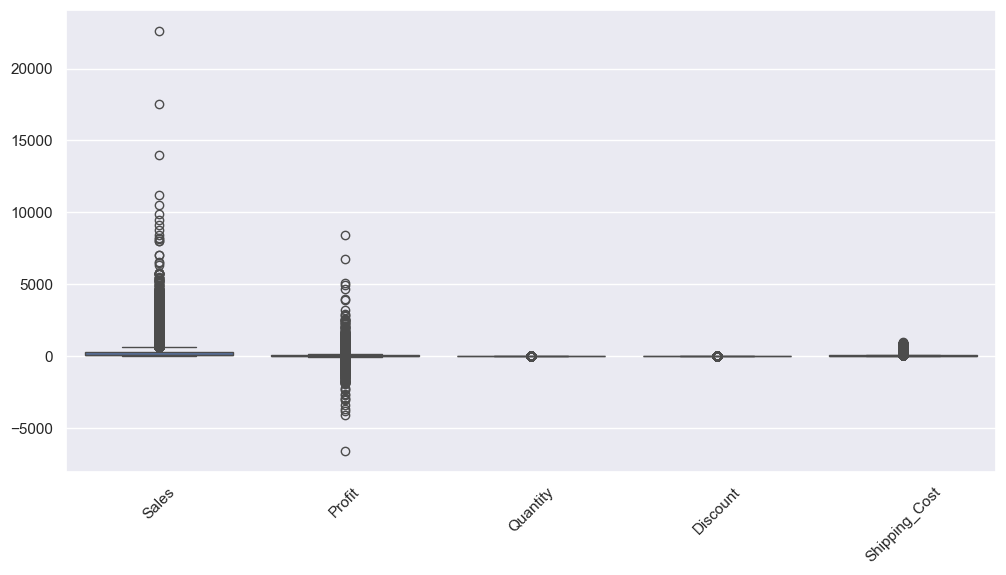

In [201]:
# ==========================================================
# BOXPLOT ANALYSIS
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Boxplots provide a visual summary of each numerical variable,
# including median values, variability, and potential outliers.
#
# This helps identify variables with extreme observations
# requiring further investigation.
# ==========================================================
num_cols= ['Sales','Profit','Quantity','Discount', 'Shipping_Cost']
plt.figure(figsize= (12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.show()

## Business Observation

Looking at how much these five numbers swing from order to order, two stand out: Sales and Shipping Cost. A typical order is worth around \$85, but a few single orders reach as high as \$22,638. Shipping usually costs about \$8, but some orders cost as much as \$933 to ship. Quantity per order barely changes — it almost always stays between 1 and 14 units. Discount is usually low or zero, but a small number of orders carry a discount as high as 85%. Profit is the most surprising one: a typical order earns only about \$9, yet some orders lose as much as \$6,600 while others earn as much as \$8,400.

## Business Insight

This tells us the business is really running two different kinds of sales at the same time: a large number of small, predictable, everyday orders, and a much smaller number of unusually large orders that swing the results a lot. The profit numbers are the biggest warning sign here — a typical order barely makes any money, and some orders lose a lot of it. Since the biggest discounts also reach very high levels, heavy discounting is a likely reason why some orders end up losing money, which we look at directly in the next chart.

## Business Recommendations

- Double-check unusually large orders (in sales or shipping cost) to confirm they are real deals and not data mistakes.
- Don't rely on "average profit" alone to judge performance — track how many orders actually lose money, not just the average.
- Look closely at orders with very high discounts, since they are the most likely cause of the big losses seen on some orders.
- Quantity per order is already stable and doesn't need attention right now.

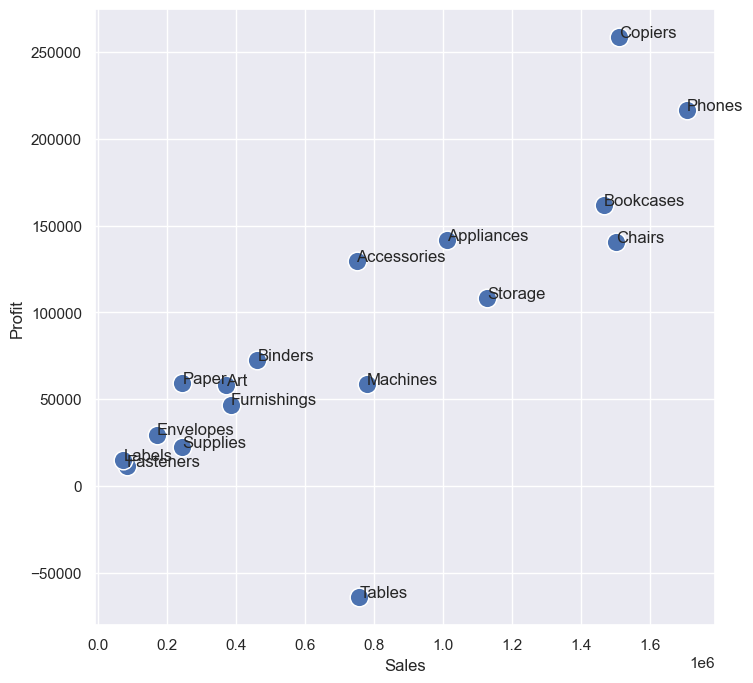

In [244]:
# ==========================================================
# RELATIONSHIP BETWEEN SALES AND PROFIT
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Determine whether higher sales consistently generate
# higher profits or whether some high-revenue transactions
# produce poor financial performance.
# ==========================================================
summary = (
    df.groupby("Sub_Category")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
)

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=summary,
    x="Sales",
    y="Profit",
    s=180
)

for i in summary.index:
    plt.text(
        summary.loc[i,"Sales"],
        summary.loc[i,"Profit"],
        i
    )

plt.show()

## Business Observation

When we group products into their 17 product lines (like Phones, Chairs, Tables, etc.), the ones that sell the most money also tend to earn the most profit — which is what you'd expect. Phones, for example, sells the most (\$1.71 million) and also earns strong profit (\$216,717). But one product line breaks this pattern completely: Tables. It sells a solid \$757,034 worth of goods, but instead of making a profit, it actually loses \$64,083. It is the only one of the 17 product lines that loses money.

## Business Insight

For almost the entire product range, more sales genuinely does mean more profit. But Tables is a clear exception, and not a small one — losing \$64,000 on three-quarters of a million dollars in sales points to a real, ongoing pricing or discounting problem, not just bad luck on a few orders.

## Business Recommendations

- Review the pricing and discounting of Tables as a priority — it is the only product line losing money.
- Don't just chase sales growth everywhere; growing sales in the wrong product line, like Tables, can actually hurt total company profit.
- Check product line profit regularly, not just sales, in future business reviews.

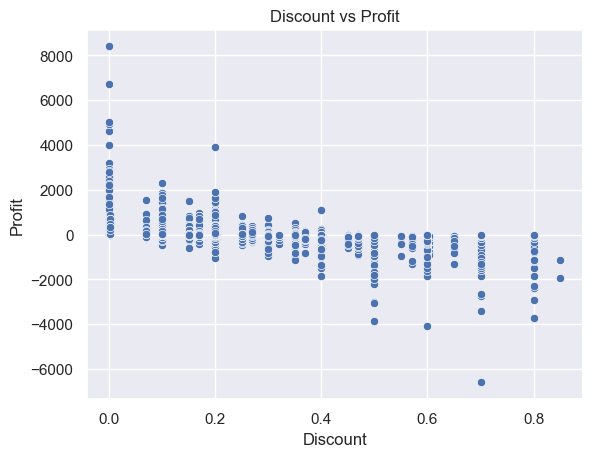

In [203]:
# ==========================================================
# DISCOUNT IMPACT ON PROFITABILITY
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Evaluate whether discount policies improve business
# performance or reduce overall profitability.
# ==========================================================
sns.scatterplot(data=df, x = 'Discount', y = 'Profit')
plt.title('Discount vs Profit')
plt.show()

## Business Observation

Looking at every single sale, a clear pattern shows up: the bigger the discount, the more likely the store is to lose money on that sale. More than half of all sales (57%) have no discount at all, and almost none of those lose money. But about 1 in 5 sales get a discount bigger than 30%, and for those, 9 out of 10 actually lose money for the store. Overall, about 1 in 4 of all sales in the entire dataset end up being a loss.

## Business Insight

Giving a discount above 30% is close to a guaranteed way to lose money on that sale, not a reasonable trade-off. Since a quarter of all sales are unprofitable, and discounting is the clearest reason visible in the data, cutting back on deep discounts is likely the single biggest opportunity to protect profit.

## Business Recommendations

- Set a maximum discount of around 20–25% for everyday sales, and require manager approval for anything higher.
- Require sign-off for any discount above 30%, since almost all sales at that level lose money.
- Use other ways to attract customers, such as bundles or loyalty rewards, instead of simply cutting the price further.
- Show sales staff the expected profit impact before they approve a big discount.

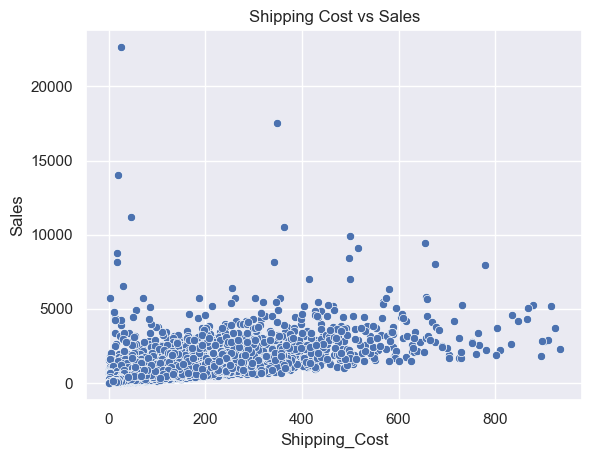

In [204]:
# ==========================================================
# SHIPPING COST VS SALES
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Examine whether larger sales values are associated
# with higher shipping costs.
# ==========================================================
sns.scatterplot(data=df, x = 'Shipping_Cost', y = 'Sales')
plt.title('Shipping Cost vs Sales')
plt.show()

## Business Observation

In general, bigger orders cost more to ship, which makes sense. But there is a group of smaller orders that cost far more to ship than they should, given how little they are worth — in these cases, the shipping cost eats up a large share of the sale.

## Business Insight

Most of the business ships efficiently, with cost matching order size. But that group of small, expensive-to-ship orders is a specific and fixable leak: these are exactly the kind of orders most likely to lose money once shipping is factored in, adding to the discounting problem seen in the previous chart.

## Business Recommendations

- Set a minimum order size to qualify for free or discounted shipping, so very small orders don't quietly lose money on freight.
- Check shipping rates for small orders that cost a lot to ship — a cheaper delivery option could save money without changing prices.
- Encourage customers to bundle small items together into bigger orders.

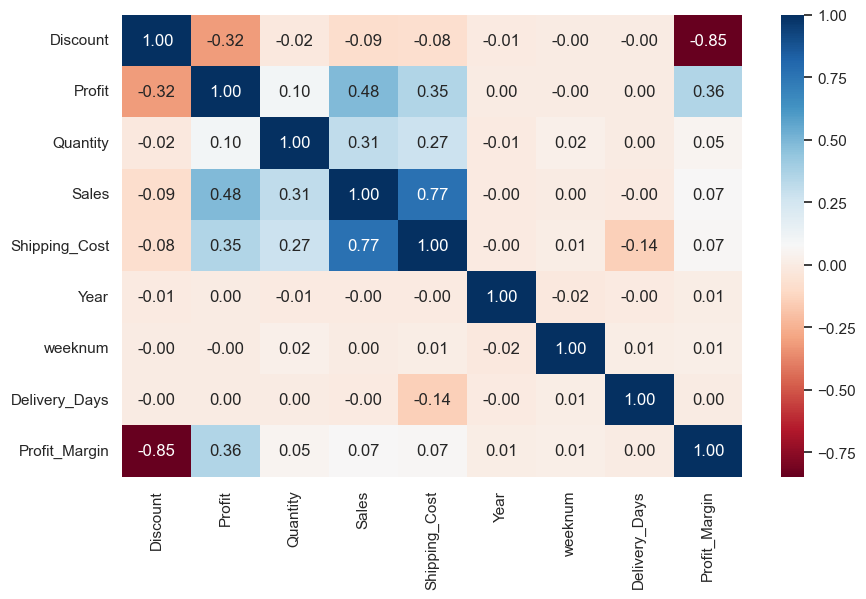

In [245]:
# ==========================================================
# CORRELATION ANALYSIS
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Measure the strength of relationships among numerical
# business variables.
#
# Understanding these relationships supports forecasting
# and predictive analytics.
# ==========================================================
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu",
    fmt=".2f"
)

plt.show()

## Business Observation

Comparing all the key numbers side by side, discount stands out as the factor most closely tied to lower profit — the bigger the discount given, the lower the profit earned, more so than any other factor on this chart. Shipping cost and order size move very closely together, which is expected. Sales and profit are somewhat connected, but not as tightly as you might think — a bigger sale does not automatically mean a bigger profit. How many years have passed makes almost no difference to profit at all.

## Business Insight

Discounting is the clearest lever management has to directly improve profit, and right now it is working against the business. The fact that sales and profit aren't as tightly linked as expected is also an important warning: simply growing sales will not automatically fix profitability — margin needs its own dedicated attention. And since time (which year it is) makes almost no difference to profit, waiting for profit to improve on its own is not a real strategy.

## Business Recommendations

- Make discount control the top priority for improving overall company profit — it is the clearest lever available.
- Don't assume growing sales alone will fix profit; build a separate plan focused specifically on margins.
- Use the strong link between shipping cost and order size to build delivery cost directly into how orders are priced.

=========================================================
## SUMMARY
=========================================================

Key findings from the exploratory analysis include:

• Sales distribution is highly skewed, with a small number of large transactions contributing significantly to total revenue.

• High sales do not always translate into high profitability.

• Increasing discounts tends to reduce profit.

• Shipping costs generally increase with order size but reveal opportunities for logistics optimization.

• Several high-value transactions represent important business opportunities and should not be treated as data errors.

Overall, the exploratory analysis identifies pricing strategy, discount management, and logistics efficiency as the primary drivers of business performance.

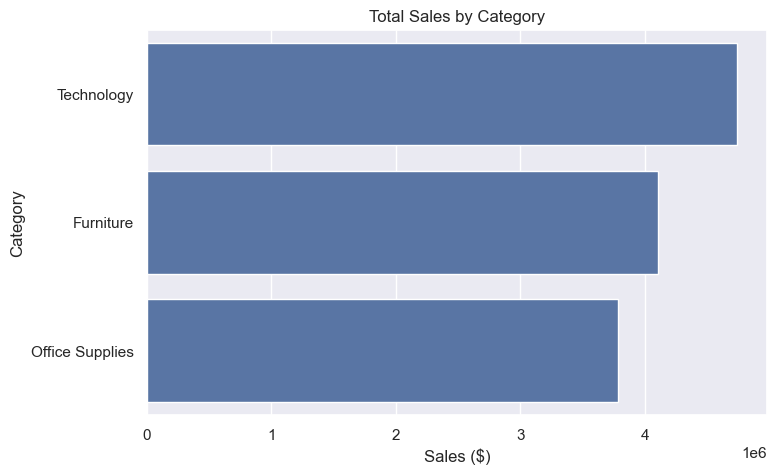

In [269]:
# ==========================================================
# SALES PERFORMANCE BY CATEGORY
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Evaluate the contribution of each product category to
# the company's total revenue.
#
# Understanding category performance helps management
# prioritize inventory, marketing investment,
# and product strategy.
# ==========================================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Total Sales by Category")
plt.xlabel("Sales ($)")
plt.ylabel("Category")

plt.show()

## Business Observation

Technology brings in the most money overall — \$4.74 million, or 37.5% of all sales — just ahead of Furniture (\$4.11 million, 32.5%) and Office Supplies (\$3.79 million, 30%). But Office Supplies is bought far more often: it makes up 61% of all individual orders, while Technology makes up only about a fifth of all orders.

## Business Insight

Technology earns the most money from a smaller number of bigger purchases, while Office Supplies earns less overall but from a much larger number of small, everyday purchases. Both matter, just in different ways — one drives big-ticket revenue, the other keeps day-to-day business steady.

## Business Recommendations

- Keep Technology well-stocked and available — even with fewer orders, each one matters more to total revenue.
- Use how often customers buy Office Supplies as a chance to also sell them Technology accessories.
- Check whether Furniture, which sells almost as much as Technology, is actually as profitable — covered in the next chart.

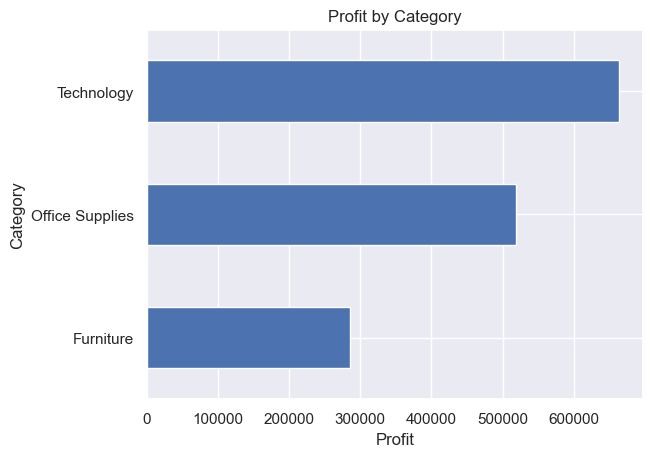

In [207]:
# ==========================================================
# PROFITABILITY BY CATEGORY
# ==========================================================
#
# BUSINESS OBJECTIVE
#
# Revenue alone does not determine business success.
#
# This analysis evaluates which product categories
# generate the highest financial returns.
# ==========================================================

category_profit = (
    df.groupby("Category")["Profit"]  
      .sum().sort_values() 
)

category_profit.plot(
    kind="barh")        
     

plt.title("Profit by Category")    
plt.xlabel("Profit")                 
                
plt.show()                             

## Business Observation

Technology doesn't just lead in sales — it leads in profit too, earning \$663,779, which is 45% of all company profit. Office Supplies earns \$518,474 (35% of profit), and Furniture earns just \$285,205 (only 19% of profit) — even though Furniture's sales are almost as high as Technology's.

## Business Insight

Technology is clearly the most valuable category for the business — it earns even more profit than its share of sales would suggest. Furniture is the opposite story: it sells a lot, but turns that into profit far less effectively than the other two categories.

## Business Recommendations

- Keep investing in Technology — it is the strongest profit driver in the business.
- Start a focused review of Furniture pricing and costs — it needs the most improvement.
- Make sure Office Supplies stays healthy too, since it earns a solid share of profit even with smaller individual sales.

In [270]:
category_summary = (
    df.groupby("Category")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum"),
          Orders=("Order_ID","nunique")
      )
)

category_summary["Profit Margin"] = (
    category_summary["Profit"] /
    category_summary["Sales"] *100
)

category_summary.sort_values("Sales",ascending=False)

,Sales,Profit,Orders,Profit Margin
Category,,,,
Technology,4744691,"663,778.73",8354,13.99
Furniture,4110884,"285,204.72",8195,6.94
Office Supplies,3787330,"518,473.83",19003,13.69


## Business Insight

When we look at how much profit each category keeps out of every dollar sold, Technology keeps about 14 cents, Office Supplies keeps almost the same, but Furniture only keeps about 7 cents — roughly half as much. What makes this interesting is that Furniture and Technology have almost the exact same number of orders, so the gap isn't about how much is sold — it's about the price or cost of each Furniture item.

## Business Recommendations

- Review Furniture pricing and discounting specifically — the issue is not sales volume, it's how much profit is kept per sale.
- Set a goal to close at least half the profit gap between Furniture and the other two categories.
- Check whether shipping or supplier costs for Furniture are higher than for smaller Technology or Office Supplies items.

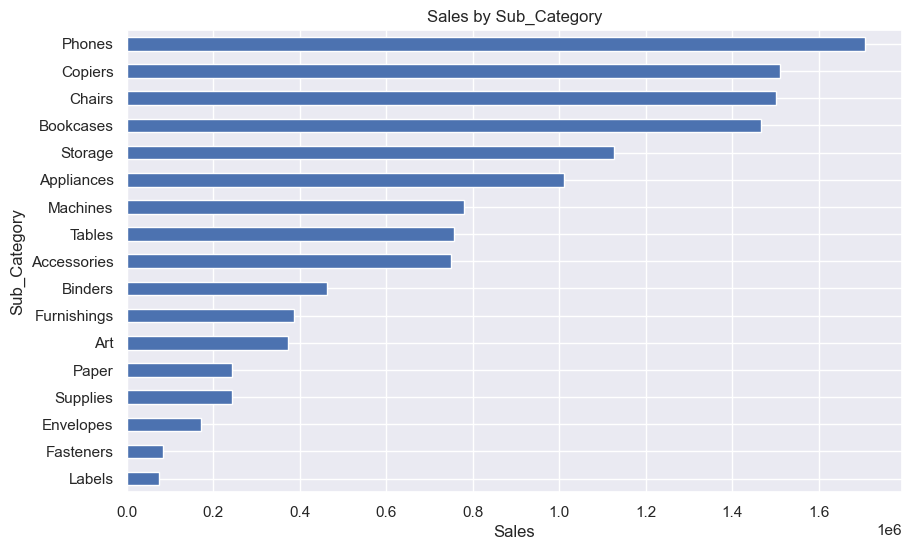

In [209]:
# Business Objective

# Which products generate the highest revenue?
subcategory_sales = (
    df.groupby("Sub_Category")["Sales"] 
      .sum().sort_values()
)
subcategory_sales.plot(
    kind="barh" ,figsize = (10,6))        
     

plt.title('Sales by Sub_Category')   
plt.xlabel("Sales")                 
                
plt.show() 

## Business Observation

Phones is the single best-selling product line at \$1.71 million, followed by Copiers (\$1.51 million) and Chairs (\$1.50 million). Together, just these three product lines bring in more money than the eleven smallest lines combined. At the other end, Labels, Fasteners and Envelopes are the three smallest sellers, together making up less than 3% of all sales.

## Business Insight

A small number of product lines carry most of the business's revenue. This means day-to-day sales health depends heavily on keeping Phones, Copiers and Chairs well-stocked and available, rather than on the catalog as a whole.

## Business Recommendations

- Keep the tightest stock control on Phones, Copiers and Chairs — they matter the most to total sales.
- Reconsider whether very small product lines like Labels and Fasteners are worth keeping, or whether they mainly support other purchases.
- Make sure there's a backup supplier for the top three product lines, so a shortage doesn't hurt overall sales.

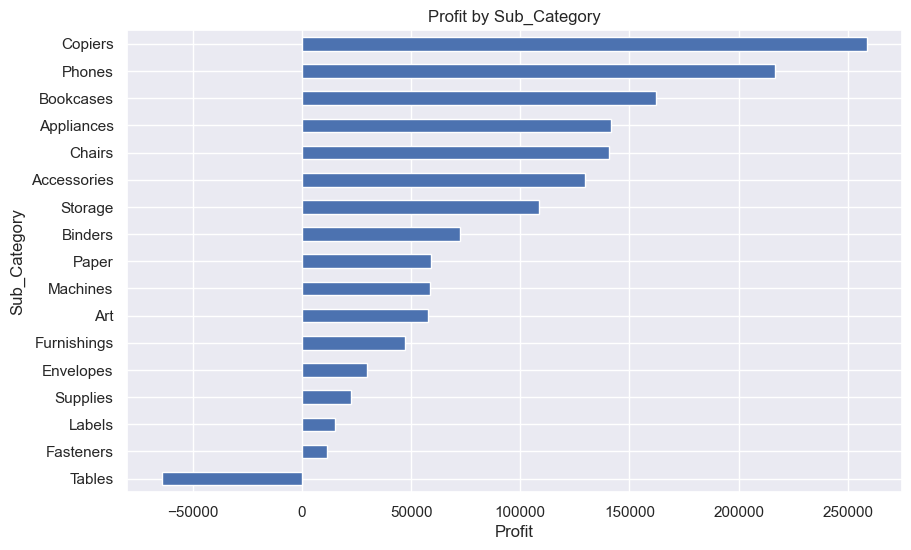

In [210]:
subcategory_profit = (
    df.groupby("Sub_Category")["Profit"] 
      .sum().sort_values()
)
subcategory_profit.plot(
    kind="barh" ,figsize = (10,6))        
     

plt.title('Profit by Sub_Category')   
plt.xlabel("Profit")                 
                
plt.show() 

## Business Observation

Copiers earns the most profit of any product line at \$258,568, ahead of Phones (\$216,717) and Bookcases (\$161,924). Tables is the only product line in the entire store that loses money overall, at a loss of \$64,083, even though it sells a solid \$757,034 worth of goods.

## Business Insight

Copiers is even more profitable than Phones, even though it sells slightly less — meaning Copiers is priced and managed more effectively. Tables being the only money-losing product line, and losing a meaningful amount, confirms it as the clearest problem area in the whole catalog.

## Business Recommendations

- Pause further discounting on Tables until pricing is reviewed — it needs urgent attention.
- Study what makes Copiers so profitable and apply the same approach to Bookcases and Chairs, which sell well but earn comparatively less.
- Decide whether small, low-profit lines like Fasteners and Labels should be merged with similar products.

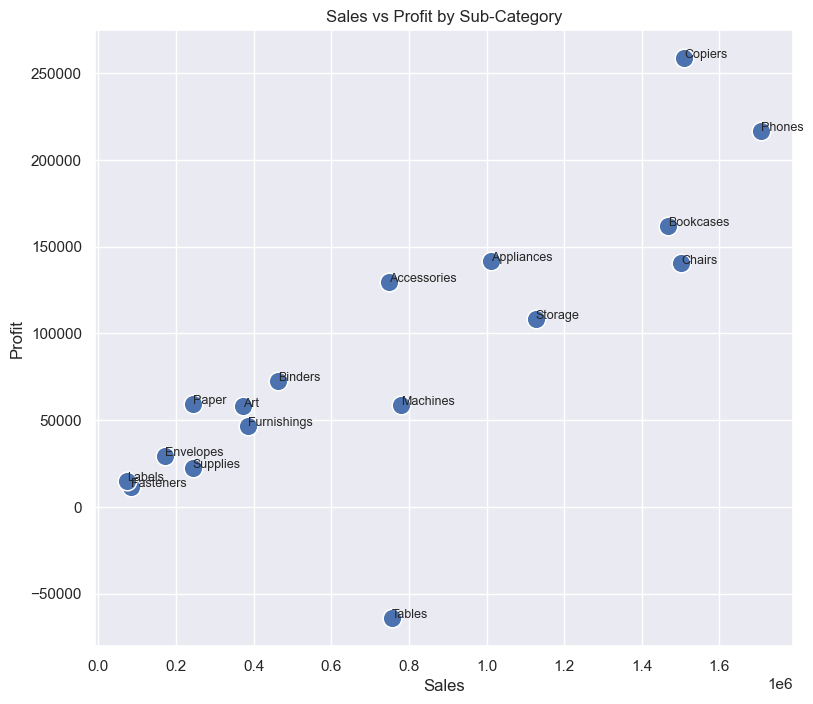

In [271]:
summary = (
    df.groupby("Sub_Category")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
)

plt.figure(figsize=(9,8))

sns.scatterplot(
    data=summary,
    x="Sales",
    y="Profit",
    s=180
)

for i in summary.index:
    plt.text(
        summary.loc[i,"Sales"],
        summary.loc[i,"Profit"],
        i,
        fontsize=9
    )

plt.title("Sales vs Profit by Sub-Category")

plt.show()

## Business Observation

Splitting all 17 product lines into groups, based on how much they sell and how much profit they make, shows four clear patterns. Six product lines — Phones, Copiers, Chairs, Bookcases, Storage and Appliances — sell well AND earn well, making them the strongest performers in the store. Tables stands alone as the one product line that sells well but actually loses money. Binders and Accessories don't sell as much, but they earn good profit for their size. The rest of the product lines sell modestly and earn modestly, and are not a priority either way.

## Business Insight

Most of the store — 6 of the 17 product lines — is performing exactly as it should: strong sales paired with strong profit. The one clear risk is Tables, which combines solid sales with a real loss. Binders and Accessories are worth protecting too, since they are small but efficient earners.

## Business Recommendations

- Focus investment and attention on the six strong performers: Phones, Copiers, Chairs, Bookcases, Storage and Appliances.
- Fix the pricing problem with Tables before considering any further investment in it.
- Protect Binders and Accessories from unnecessary discounting — they are small but valuable.
- Don't prioritize new spending on the smaller, low-profit product lines for now.

In [272]:
# Profit Margin
subcategory = (
    df.groupby("Sub_Category")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
)

subcategory["Margin"] = (
    subcategory["Profit"] /
    subcategory["Sales"]*100
)

subcategory.sort_values("Margin",ascending=False)

,Sales,Profit,Margin
Sub_Category,,,
Paper,244307,"59,207.68",24.23
Labels,73433,"15,010.51",20.44
Envelopes,170926,"29,601.12",17.32
Accessories,749307,"129,626.31",17.30
Copiers,1509439,"258,567.55",17.13
Binders,461952,"72,449.85",15.68
Art,372163,"57,953.91",15.57
Appliances,1011081,"141,680.59",14.01
Fasteners,83254,"11,525.42",13.84


## Business Objective

Rank product lines by how much profit they keep from every dollar of sales, not just by how much profit they make in total.

## Business Observation

Paper keeps the most profit per dollar sold of any product line — about 24 cents out of every dollar — followed by Labels (20 cents) and Envelopes (17 cents). Tables is the only product line that loses money per dollar sold, and Machines and Supplies also keep less profit per dollar than most other lines.

## Business Insight

This shows something different from the total-profit view earlier: Paper and Labels don't sell a lot in total, but they are actually the most efficient earners in the whole store — they keep more profit per dollar sold than even Copiers, which earns more total profit dollars simply because it sells so much more.

## Business Recommendations

- Use "profit kept per dollar sold" as well as total profit dollars when deciding which product lines deserve protection from discounting.
- Learn from Paper and Labels' pricing approach and apply it to similar Office Supplies items.
- Confirm again that Tables is the product line needing the most urgent pricing attention, since it loses money both in total and per dollar sold.

## GEOGRAPHICAL ANALYSIS

***Business Goal***

Identify the geographical markets driving business growth.

Text(0.5, 1.0, 'Top 10 Sales by Country')

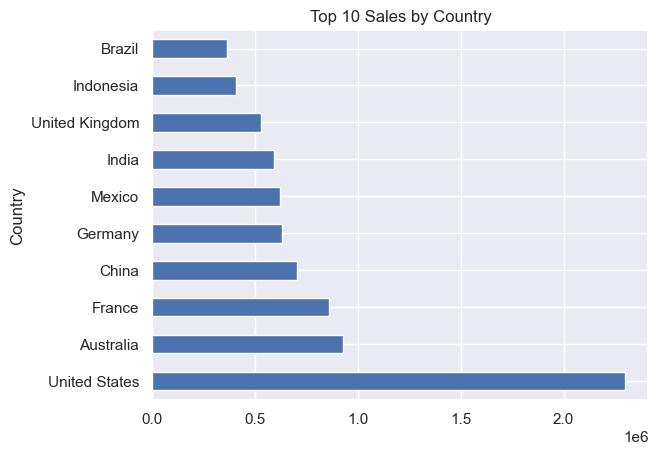

In [211]:
#Top Country By Sales
# Business Objective
# Identify the countries generating the highest revenue in order to understand where the company's strongest commercial opportunities exist.
top_country = df.groupby('Country')['Sales'].sum().sort_values(ascending = False)\
.head(10)
top_country.plot(kind= 'barh')
plt.title('Top 10 Sales by Country')

## Business Observation

The United States is by far the biggest market, bringing in \$2.3 million — about 18% of all company sales, more than double the next country. Australia comes second (\$925K) and France third (\$859K). Altogether, just 10 countries, out of 147 the store sells to, bring in almost two-thirds of all sales.

## Business Insight

The company's revenue depends heavily on a small number of countries. The United States alone is so important that any slowdown there would be felt across the whole business.

## Business Recommendations

- Protect the US market first and foremost — it is the single most important country by far.
- Study what makes the next group of strong countries (Australia, France, China, Germany) successful, to see if it can be repeated elsewhere.
- Focus resources on the top 10 countries, since they already deliver most of the revenue.

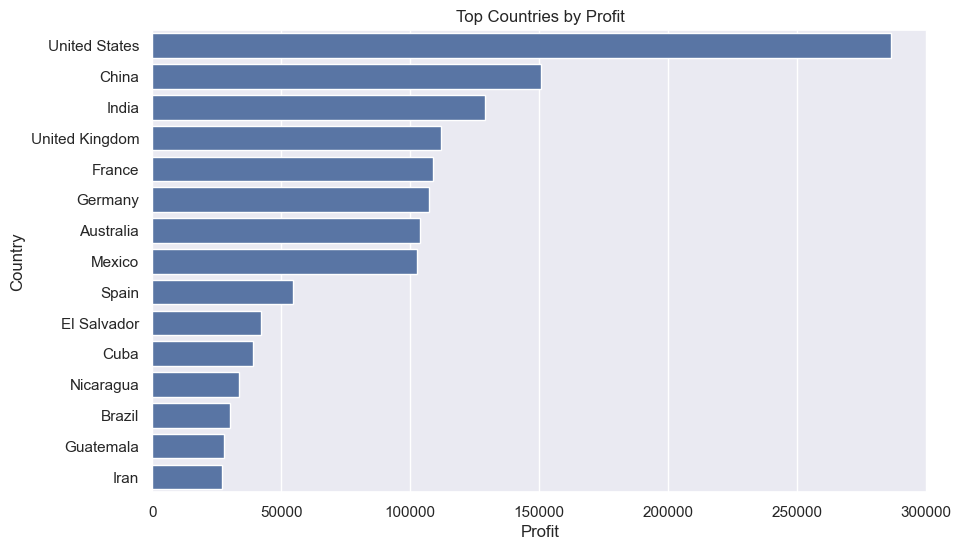

In [275]:
# Top Country by Profit
# Business Objective
# Determine which countries generate the greatest financial returns rather than simply the highest sales.

country_profit = (
    df.groupby("Country")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
      .sort_values("Profit",ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=country_profit,
    x="Profit",
    y=country_profit.index
)

plt.title("Top Countries by Profit")

plt.show()

## Business Observation

The United States leads on profit too. But below that, the order changes: China and India both earn more profit than Australia, even though Australia sells much more than either of them. Australia, the store's 2nd biggest market by sales, drops to 7th place on profit.

## Business Insight

Selling a lot doesn't always mean earning a lot. China and India are turning their sales into profit more efficiently than Australia is — the clearest sign in the whole dataset that some countries are better at making money from what they sell, not just at selling more.

## Business Recommendations

- Study how China and India price and discount their products, and see if the same approach could help Australia earn more.
- Take a closer look at business terms and discounting practices specifically in Australia.
- When setting country sales targets, measure profit, not just sales.

Text(0.5, 1.0, 'Sales by Region')

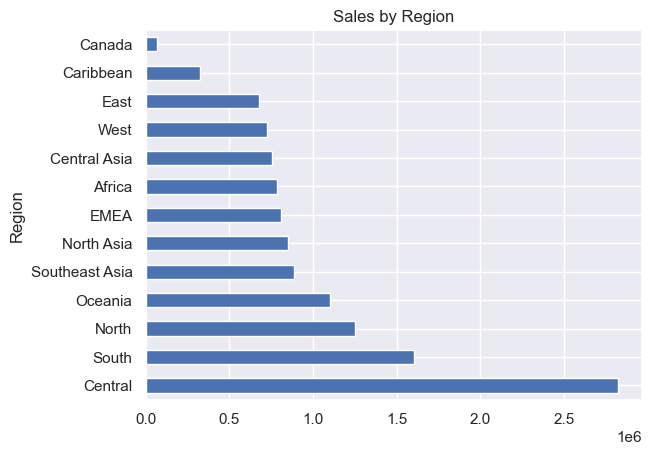

In [212]:
# Region Sales
df.groupby('Region')['Sales'].sum().sort_values(ascending= False).plot(kind='barh')
plt.title('Sales by Region')


## Business Observation

The Central region is the top performer, bringing in \$2.82 million — over a fifth of all company sales — well ahead of South and North. Canada is by far the smallest region, contributing less than 1% of total sales.

## Business Insight

A handful of regions carry most of the business. Canada currently barely shows up in the numbers — either it's an untapped opportunity, or it's simply not a priority market yet.

## Business Recommendations

- Keep supporting the Central region, the company's strongest.
- Decide whether Canada is worth more investment, or should stay a lower priority for now.
- Look at what's working in Central and see if it can be applied to mid-sized regions.

Text(0.5, 1.0, 'Sales by Market')

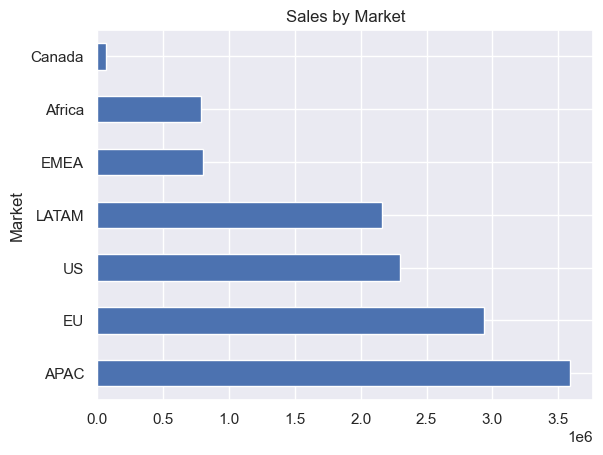

In [213]:
#Sales By Markets
df.groupby('Market')['Sales'].sum().sort_values(ascending= False).plot(kind='barh')
plt.title('Sales by Market')

## Business Observation

APAC is the leading market with \$3.59 million in sales, followed by EU (\$2.94 million) and the US (\$2.30 million). Together, these top four markets (APAC, EU, US, LATAM) bring in about 87% of all sales, while EMEA, Africa and Canada combined bring in the rest.

## Business Insight

The business is genuinely spread across several strong markets rather than depending on just one, which is a healthy sign. But EMEA, Africa and Canada are clearly underdeveloped compared with the other markets.

## Business Recommendations

- Keep investing evenly across APAC, EU, US and LATAM — all four matter a lot to total revenue.
- Consider targeted growth plans for EMEA and Africa, which already have decent scale.
- Decide on a clear strategy for Canada, which remains very small.

Text(0.5, 1.0, 'Top 10 Sales by City')

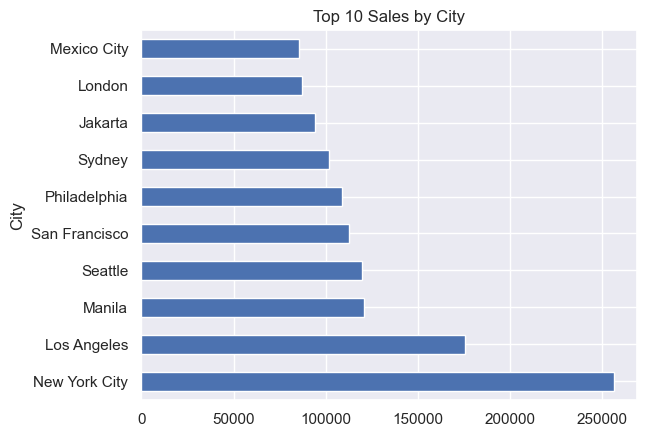

In [215]:
#Sales By City
top_city = df.groupby('City')['Sales'].sum().sort_values(ascending= False)\
.head(10)
top_city.plot(kind='barh')
plt.title('Top 10 Sales by City')

## Business Observation

New York City is the top-selling city (\$256,397), followed by Los Angeles and Manila. But even together, the top 10 cities only make up about 10% of total sales — much less concentrated than what we saw at the country level, where the top 10 countries make up almost two-thirds of sales.

## Business Insight

No single city dominates the business the way the United States dominates among countries. Sales are spread across many mid-sized cities rather than depending on just a few.

## Business Recommendations

- Keep focusing on countries and regions as the main planning level, since city-level sales are fairly spread out.
- Use New York and Los Angeles as test markets for new products or promotions.
- Don't over-invest in city-specific logistics beyond the current top performers.

Text(0.5, 1.0, 'Top 10 Sales by State')

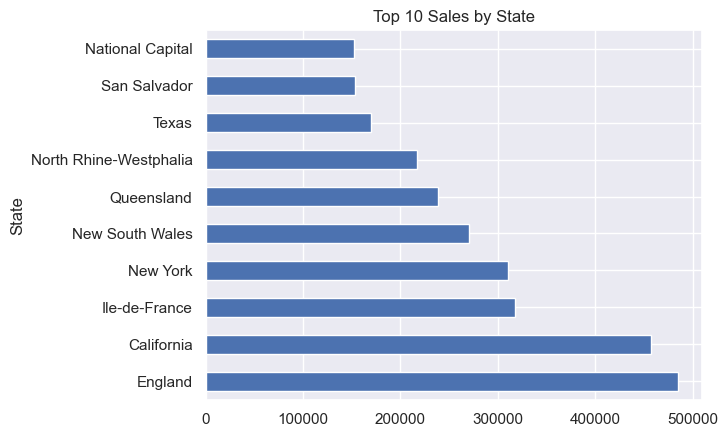

In [216]:
# Sales By State
top_city = df.groupby('State')['Sales'].sum().sort_values(ascending= False)\
.head(10)
top_city.plot(kind='barh')
plt.title('Top 10 Sales by State')

## Business Observation

England is the top state/region by sales (\$485,166), just ahead of California (\$457,731). Together, the top 10 states/regions make up about 22% of total sales — more concentrated than cities, but less than countries.

## Business Insight

The strongest states and regions line up closely with the strongest countries already identified, showing these successful markets reinforce each other rather than telling separate stories.

## Business Recommendations

- Keep investing in the leading states/regions identified here.
- Look at whether California and New York, both strong US states, could support a wider product range.
- Treat the top 10 states/regions as priority areas for local marketing.

Text(0.5, 1.0, 'Top 10 Customers by Sales')

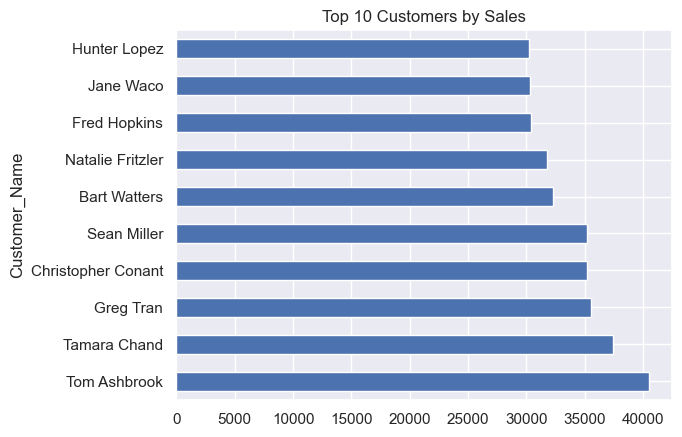

In [217]:
#Customers by Sales
top_city = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending= False)\
.head(10)
top_city.plot(kind='barh')
plt.title('Top 10 Customers by Sales')

## Business Observation

Tom Ashbrook is the top customer by total spend (\$40,489), followed by Tamara Chand and Greg Tran. But even the biggest customer only makes up 0.32% of total sales, and the top 10 customers together make up just 2.68%.

## Business Insight

Unlike countries, no single customer or small group of customers is critical to the business — spending is spread across a very large number of people. That's good news for stability, since losing one customer barely matters, but it also means there's no small "VIP" group to focus on for a quick sales boost.

## Business Recommendations

- Don't build customer strategy around a small VIP list — no single customer matters enough to justify that.
- Focus on getting the broad customer base to spend a little more, rather than chasing a few big spenders.
- Look at how often customers come back to buy again, not just how much they've spent once.

Text(0.5, 1.0, 'Top 10 Best Customers by Profit')

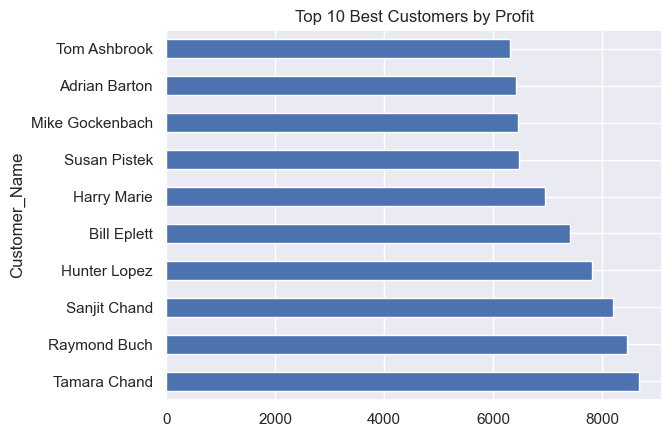

In [218]:
# Customers by Profit
top_city = df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending= False)\
.head(10)
top_city.plot(kind='barh')
plt.title('Top 10 Best Customers by Profit')

## Business Observation

Tamara Chand brings in the most profit (\$8,673), followed by Raymond Buch and Sanjit Chand. Interestingly, only 3 of the top 10 customers by spending also appear in the top 10 by profit — most of the biggest spenders are not the most profitable customers.

## Business Insight

Spending the most doesn't mean generating the most profit. What matters more is what a customer buys, and whether they received a big discount, not simply how much they spent in total.

## Business Recommendations

- Focus retention efforts on the customers who bring the most profit, not just the biggest spenders.
- Look at what these profitable customers tend to buy, and encourage similar purchases from others.
- Track both spending and profit per customer, not spending alone.

<function matplotlib.pyplot.show(close=None, block=None)>

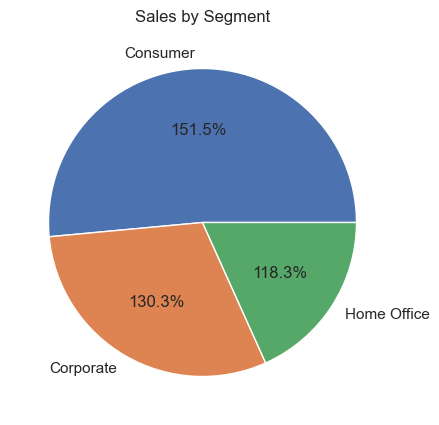

In [219]:
#Sales by Segment
segment_sales = df.groupby("Segment")['Sales'].sum()
plt.figure(figsize=(8,5))
plt.pie(segment_sales,labels=segment_sales.index,autopct = "1%.1f%%")
plt.title('Sales by Segment')
plt.show

## Business Observation

Individual consumers (the "Consumer" segment) make up just over half of all sales (51.5%) — more than Corporate (30%) and Home Office (18%) combined.

## Business Insight

The business leans heavily on everyday individual customers, but Corporate and Home Office together still make up almost half of all sales — they matter too and shouldn't be treated as an afterthought.

## Business Recommendations

- Keep prioritizing marketing toward everyday Consumer buyers, since they drive over half of revenue.
- Build a specific growth plan for the Corporate segment rather than treating it the same as Consumer.
- Consider whether Home Office customers have different needs that deserve their own offer.

Text(0.5, 1.0, 'Orders by Segment')

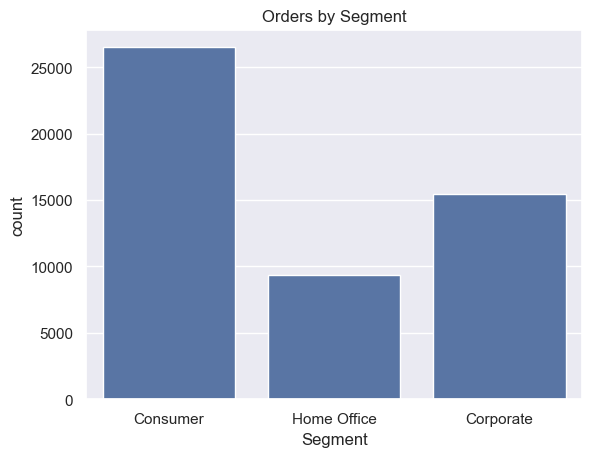

In [220]:
# Counting orders by Segmwnt
sns.countplot(data=df, x = 'Segment')
plt.title('Orders by Segment')

## Business Observation

Consumers also place by far the most individual orders (51.7% of all orders), which closely matches their 51.5% share of total sales.

## Business Insight

Because the order share and sales share for Consumers are almost identical, average order size is similar across all customer types. Consumer's lead comes from more people buying, not from bigger individual purchases.

## Business Recommendations

- Grow Consumer sales mainly by encouraging repeat purchases, since order size is already typical.
- For Corporate and Home Office, test whether encouraging bigger orders — rather than more frequent ones — grows sales faster.
- Track order count and order size separately for each customer type going forward.

Text(0.5, 1.0, 'Top 10 Product by Sales')

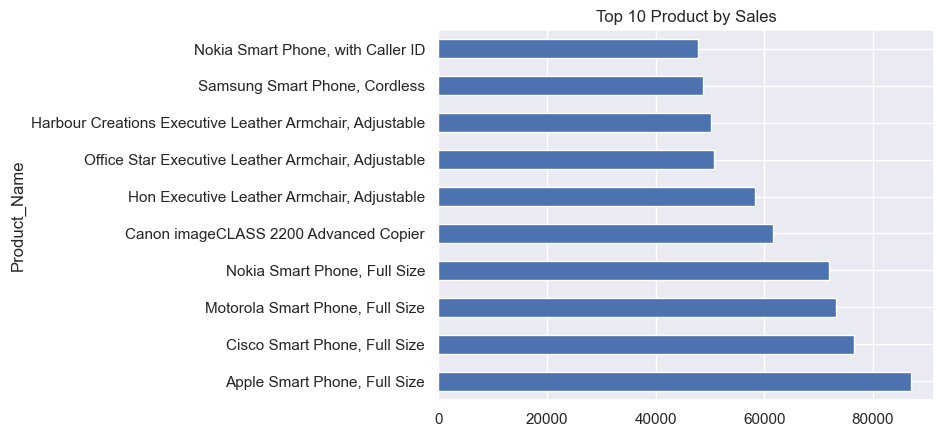

In [221]:
# Top Products by Sales
top_product =df.groupby('Product_Name')['Sales'].sum().sort_values(ascending= False)\
.head(10)
top_product.plot(kind='barh')
plt.title('Top 10 Product by Sales')

## Business Observation

Smartphones from four different brands (Apple, Cisco, Motorola, Nokia) are the four best-selling individual products. A copier and three different office chairs also make the top 10. Even so, these 10 best-sellers only make up about 5% of total sales, out of nearly 3,800 different products sold.

## Business Insight

The best-selling products are concentrated in phones and premium office chairs/copiers, matching what we already know: Phones and Copiers are strong product lines overall. But since the top 10 products are only 5% of total sales, the business isn't dependent on a handful of bestsellers — it relies on a broad range of products.

## Business Recommendations

- Keep close stock control on the top-selling phones and the leading copier model.
- Check whether offering three different office chair options is helping sales, or whether the range could be simplified.
- Keep managing the wider product catalog actively, since no small group of products can carry total sales alone.

Text(0.5, 1.0, 'Top 10 Most Profitable Products')

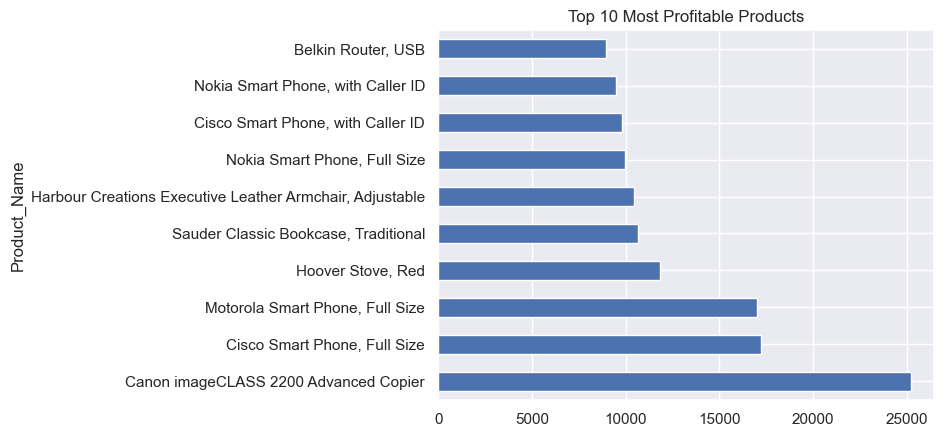

In [222]:

# Top Profitable Products
top_product =df.groupby('Product_Name')['Profit'].sum().sort_values(ascending= False)\
.head(10)
top_product.plot(kind='barh')
plt.title('Top 10 Most Profitable Products')

## Business Observation

The Canon imageCLASS copier is the single most profitable product (\$25,200), earning almost 50% more profit than the next-best product, a Cisco smartphone (\$17,239). A stove and a bookcase also appear in the top 5, showing profitable products aren't limited to Technology alone.

## Business Insight

Most of the top-selling products (6 of the top 10) are also among the most profitable, which is a good sign — it means the store's bestsellers are priced well, not just popular.

## Business Recommendations

- Promote the Canon copier more — it is the single strongest individual earner.
- Keep pricing steady on the smartphones that are both best-selling and highly profitable.
- Look for more profitable products outside Technology, like the stove and bookcase, especially within Furniture, which needs a profit boost overall.

Text(0.5, 1.0, 'Top 10 Least Profitable Products')

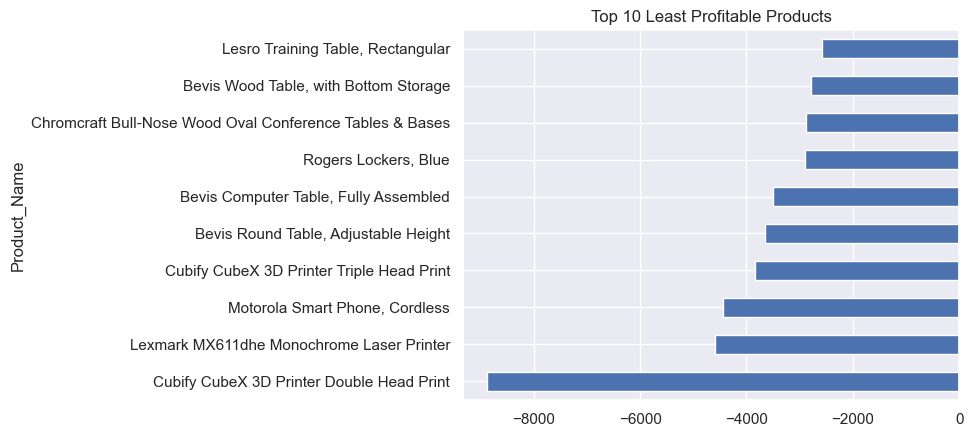

In [223]:
# Least Profitable Products
low_product =df.groupby('Product_Name')['Profit'].sum().sort_values()\
.head(10)
low_product.plot(kind='barh')
plt.title('Top 10 Least Profitable Products')

## Business Observation

A specific 3D printer (the Cubify CubeX, Double Head model) is the single biggest money-loser, at a loss of \$8,880 — almost double the next-worst product. A second version of the same 3D printer also appears in the bottom 10. Four of the ten worst products are Furniture items, matching what we already know about Furniture's weaker profit performance. Around 1 in 6 products in the whole catalog (18%) lose money.

## Business Insight

The same 3D printer showing up twice in the worst-performing list suggests a specific, ongoing problem with that product, not just a one-time mistake. The number of Furniture products on this list also confirms that Furniture's profit problem is concentrated in a few specific items, not spread evenly.

## Business Recommendations

- Review pricing and costs for the Cubify 3D printer line specifically — it is the clearest repeat problem.
- Decide whether to reprice, redesign, or drop the consistently loss-making Furniture products on this list.
- Set up a regular check of the worst-performing products, since almost 1 in 5 products are currently losing money, and this wouldn't be obvious without a dedicated review.

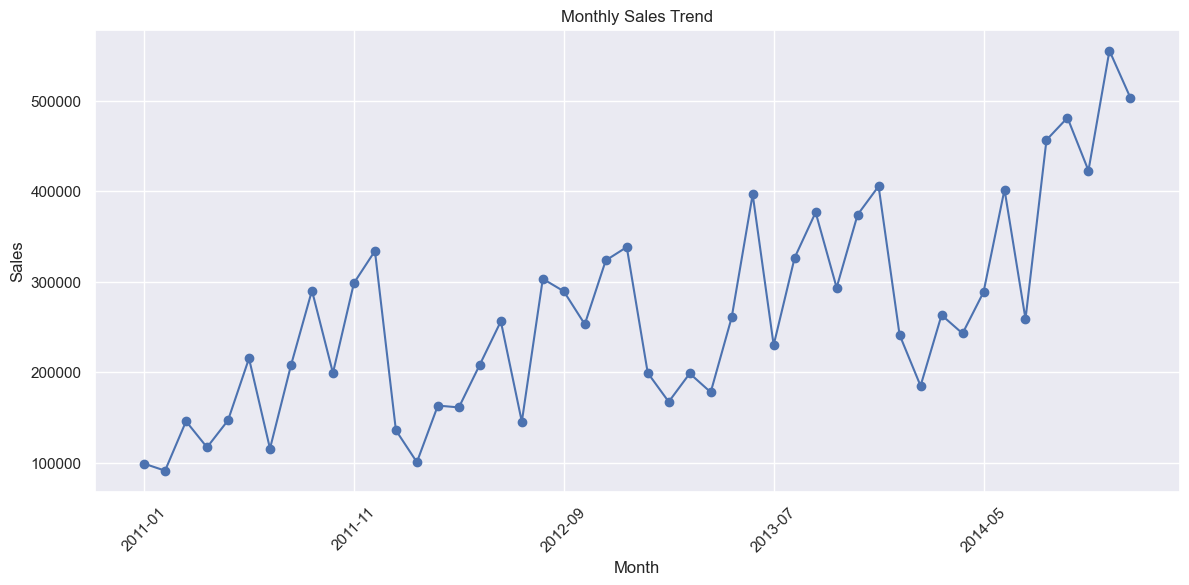

In [225]:
# Monthly Sales Trend
monthly = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.astype(str)
plt.figure(figsize=(14,6))
monthly.plot(marker='o')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()

## Business Observation

Every single year in the data, from 2011 to 2014, follows the same pattern: February is always the slowest month, and November/December are always the busiest. Total sales also grew every year, from \$2.26 million in 2011 to \$4.30 million in 2014 — almost double in just four years.

## Business Insight

This isn't random — the same slow-and-busy pattern repeats every year, so it can be planned for with confidence. Combined with steady year-on-year growth, this shows a business that grows reliably and has a predictable end-of-year rush.

## Business Recommendations

- Plan stock and staffing ahead of the November-December rush every year, since this pattern is consistent.
- Use the quiet January-February period for maintenance, system upgrades, or off-season promotions.
- Build the historical growth rate, roughly 20-27% per year, into future sales forecasts.

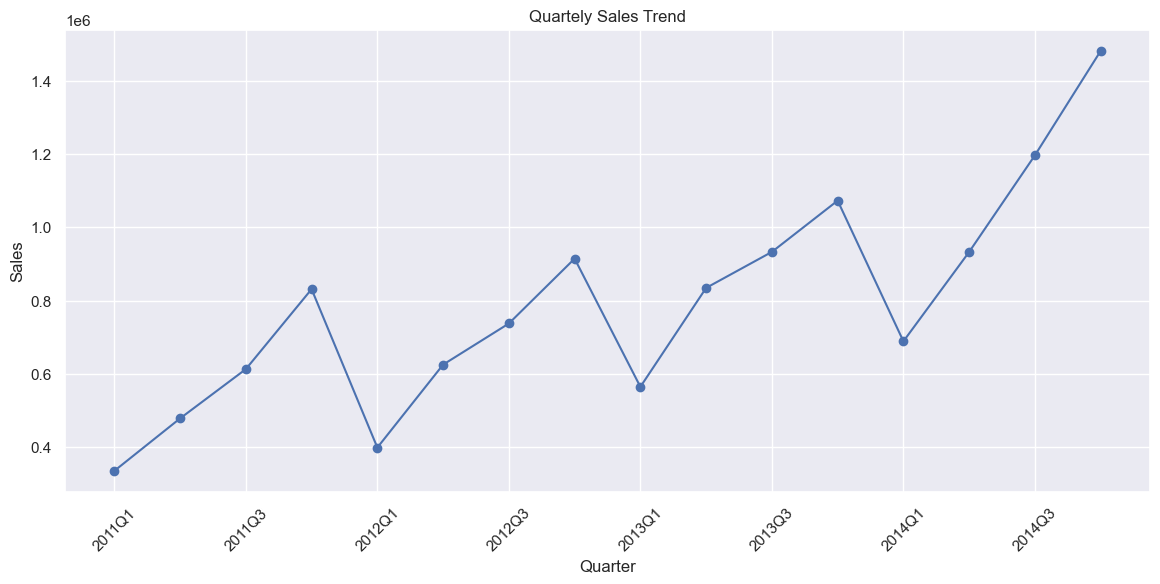

In [226]:
#Quarterly Sales Trend
Quarter = df.groupby(df['Order_Date'].dt.to_period('Q'))['Sales'].sum()
Quarter.index = Quarter.index.astype(str)
plt.figure(figsize=(14,6))
Quarter.plot(marker='o')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.title('Quartely Sales Trend')
plt.show()

## Business Observation

Every quarter is stronger than the one before it, every single year — Q1 is always the slowest and Q4 is always the busiest. This holds true in every year in the data, without exception.

## Business Insight

This confirms, at a bigger-picture level, the same pattern seen in the monthly numbers: the business reliably builds up through the year and peaks at the end. Because it happens every year without fail, it's a solid basis for planning.

## Business Recommendations

- Use the steady Q1-to-Q4 build-up as the standard model for sales forecasting each year.
- Plan cash flow and supplier payments around the predictable Q4 surge.
- Treat any year where this pattern doesn't hold as an early warning sign worth investigating.

<function matplotlib.pyplot.show(close=None, block=None)>

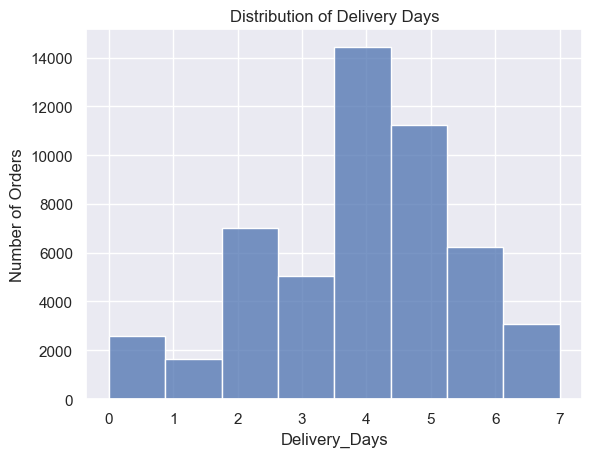

In [227]:
#Delivery Days Distribution
df['Delivery_Days']= (df['Ship_Date']-df['Order_Date']).dt.days
df['Delivery_Days'].describe()
sns.histplot(df['Delivery_Days'], bins = 8)
plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery_Days')
plt.ylabel('Number of Orders')
plt.show


## Business Observation

No order ever takes more than 7 days to arrive. Most orders (60%) arrive within 4 days. Customers who choose the cheapest shipping option take the longest on average (5 days), while those who pay for faster shipping get their orders in as little as 2 days, or even the same day.

## Business Insight

Delivery is actually working well across the board — a 7-day maximum with no major delays is a strong result. The slightly longer wait for cheap shipping isn't a problem; it's simply the trade-off customers are choosing when they pick the lower-cost option.

## Business Recommendations

- No urgent action is needed on delivery times — they are already strong and consistent.
- Keep an eye on the cheapest shipping option to make sure its average delivery time doesn't get any longer.
- Clearly show expected delivery times for each shipping option at checkout, so customers can choose confidently.

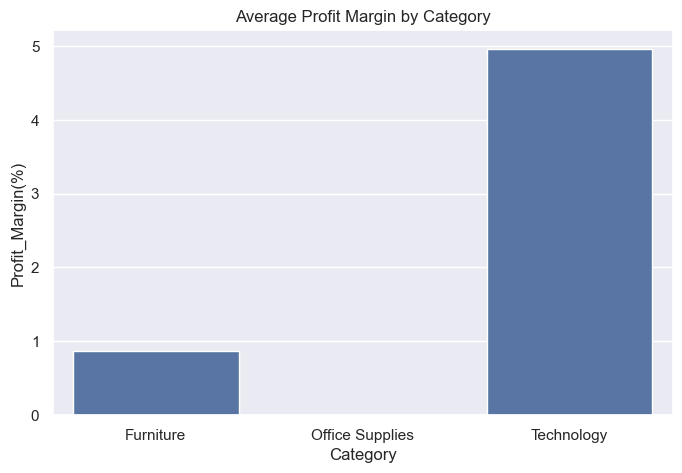

In [233]:
#Average Profit Margin by Category
df['Profit_Margin'] = (df['Profit']/ df["Sales"])*100
margin = df.groupby('Category')['Profit_Margin'].mean()
plt.figure(figsize = (8,5))
sns.barplot(x=margin.index, y = margin.values)
plt.title('Average Profit Margin by Category')
plt.ylabel('Profit_Margin(%)')
plt.show()

## Business Observation

This particular chart shows Technology with the best profit-per-dollar (about 5 cents per dollar) and Furniture with a smaller but still positive amount (under 1 cent per dollar). Office Supplies shows a strange, broken result here, caused by a single sale in the data where nothing was actually sold (\$0) but the store still recorded a small loss — this one unusual entry breaks the calculation for the entire category in this specific chart.

## Business Insight

This is a good reminder that a single incorrect or unusual entry in a dataset can throw off an entire result if it isn't checked. The earlier profit-per-dollar numbers we calculated (Technology about 14 cents, Office Supplies close behind, Furniture about 7 cents) are the reliable numbers to trust and act on, not this specific chart.

## Business Recommendations

- Always double-check totals using more than one calculation method before reporting them to leadership.
- Add a check that flags any sale recorded with \$0 in sales, so a single odd entry can't quietly distort results.
- Continue to treat Technology as the strongest category on profit-per-dollar, and Furniture as the one most needing improvement.

In [238]:
# Calculate total number of unique orders in the dataset
total_orders = df["Order_ID"].nunique()
print(f"Total Orders : {total_orders:,}")

# Calculate total sales revenue across all transactions
total_sales = df["Sales"].sum()
print(f"Total Sales : ${total_sales:,.2f}")

# Calculate total profit generated from all transactions
total_profit = df["Profit"].sum()

print(f"Total Profit : ${total_profit:,.2f}")
# Average Order Value

print(f'Agerage Order Value : $',df['Sales'].mean())

# Calculate total quantity of items sold across all orders
total_quantity = df["Quantity"].sum()

print(f"Total Quantity : {total_quantity:,}")

# Calculate the average discount rate applied across all transactions
average_discount = df["Discount"].mean()

print(f"Average Discount : {average_discount:.1%}")

# Calculate the average sales value per transaction
average_sales = df["Sales"].mean()

print(f"Average Sales per Transaction : ${average_sales:,.2f}")

#Average Delivery Day
print('Average Delivery Day :',df['Delivery_Days'].mean())

Total Orders : 25,035
Total Sales : $12,642,905.00
Total Profit : $1,467,457.29
Agerage Order Value : $ 246.49844024176252
Total Quantity : 178,312
Average Discount : 14.3%
Average Sales per Transaction : $246.50
Average Delivery Day : 3.96937024761162


# EXECUTIVE SUMMARY

This report looked at 51,290 sales made between 2011 and 2014, across 147 countries and 3 major product categories, adding up to \$12.6 million in total sales and \$1.47 million in profit — meaning the store keeps about 11-12 cents of profit for every dollar sold.

## Key Findings

- Sales have grown steadily every year, almost doubling from 2011 (\$2.26M) to 2014 (\$4.30M).
- Technology is the strongest category — it sells the most AND earns the most profit per dollar sold.
- Furniture sells almost as much as Technology but earns only about half as much profit per dollar — a clear opportunity for improvement.
- Big discounts, above 30%, are closely tied to losses: 9 out of 10 heavily discounted sales lose money, and a quarter of all sales overall are unprofitable.
- Tables is the one product line losing money overall, despite solid sales.
- A small number of countries (10 out of 147) bring in almost two-thirds of all sales, led by the United States.
- Selling a lot doesn't always mean earning a lot — China and India earn more profit than higher-selling Australia.
- No single customer is critical to the business — even the biggest customer is only 0.32% of total sales.
- Sales follow a very reliable yearly pattern: slow in February, busy in November/December, every single year.
- Delivery is fast and reliable — no order takes more than 7 days.

## Business Strengths

- A strong, highly profitable Technology category leading both sales and profit.
- Steady, predictable yearly growth with a reliable end-of-year sales boost.
- A broad customer base that isn't dependent on any single customer.
- Fast, dependable delivery across all shipping options.

## Business Weaknesses

- Furniture earns far less profit per dollar sold than the other two categories.
- Tables is actively losing the business money.
- Heavy discounting, above 30%, is strongly linked to unprofitable sales.
- About 1 in 6 products in the catalog currently lose money, including a recurring problem with one specific 3D printer model.

## Risks

- Heavy reliance on the US and a small group of top countries means any slowdown there would hit the whole business hard.
- Continuing to discount heavily could keep hurting profit even while total sales keep growing.
- If left unaddressed, Furniture's weak profit will keep dragging down the company's overall results.

## Growth Opportunities

- Learn from China and India's pricing approach and apply it to less profit-efficient markets like Australia.
- Use frequent Office Supplies purchases as a chance to also sell Technology accessories.
- Apply Copiers' pricing approach, the most profitable product line, to similar products like Bookcases and Chairs.
- Grow EMEA and Africa, both of which already have decent sales but remain well behind the top markets.

## Strategic Recommendations

1. Set clear limits on discounts — cap them around 20-25% for everyday sales, and require approval for anything higher.
2. Start a focused pricing review of Furniture, especially Tables, the one product line currently losing money.
3. Always double-check profit numbers using more than one calculation method, since a single unusual entry can distort results.
4. Keep the US and top markets strong, while also growing higher-profit markets like China and India.
5. Set up a regular review of the lowest-performing products, since almost 1 in 5 currently lose money.
6. Use the reliable yearly sales pattern — slow start, strong finish — to plan stock, staffing, and promotions ahead of time.

Overall, three things stand out as the biggest opportunities to improve profit: controlling discounts, fixing Furniture's pricing, and growing in countries that convert sales into profit more efficiently.